---
# I. Installs & Imports

In [3]:
# ~~~~~~~~~~~~~~~~~~~~~~~ Required Installs ~~~~~~~~~~~~~~~~~~~~~~~ #
# !pip install torch --index-url https://download.pytorch.org/whl/cu121
# !pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras
# !pip install lightgbm catboost tqdm
# !pip install --upgrade jupyter
# !pip install -r ./requirements.txt

# --- Core Data Handling & Visualization ---
!pip install torch numpy pandas matplotlib seaborn

# --- Machine Learning Libraries ---
!pip install scikit-learn lightgbm catboost tensorflow keras

# --- Utilities & Tools ---
!pip install tqdm jupyter
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ #

import os
import zipfile
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import time
import kagglehub
from datetime import datetime
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_absolute_error,
    r2_score,
    make_scorer,
)
from lightgbm import LGBMRegressor
from tqdm.auto import tqdm
from catboost import CatBoostRegressor as _CatBoostRegressor
from sklearn.base import BaseEstimator, RegressorMixin

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # run on GPU
print(f"\nUsing device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 112.1 MB/s eta 0:00:00
  Attempting uninstall: jupyter-server
    Found existing installation: jupyter_server 2.18.2
    Uninstalling jupyter_server-2.18.2:
      Successfully uninstalled jupyter_server-2.18.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.18.2, but you have jupyter-server 2.20

---
# II. Exploratory Data Analysis & Reconstruction (Quality Prediction in a Mining Process)

This section conducts Exploratory Data Analysis for the Quality Prediction in a Mining Process dataset that can be found at:
    https://www.kaggle.com/datasets/edumagalhaes/quality-prediction-in-a-mining-process

## 1. Loading Dataset, Datetime Conversion and Indexing

In [4]:
# Download the dataset with kaggel API (automatically aviods multiple download)
df_mining_path = os.path.join(kagglehub.dataset_download("edumagalhaes/quality-prediction-in-a-mining-process"), "MiningProcess_Flotation_Plant_Database.csv")

# Load dataset
df_mining = pd.read_csv(df_mining_path, decimal=',')

# Datetime Conversion and Indexing
df_mining['date'] = pd.to_datetime(df_mining['date'])
df_mining = df_mining.set_index('date')

# Display Dataset Head
print('\ndf_mining ', df_mining.shape, ':', sep='')
with pd.option_context('display.max_columns', None):
    display(df_mining.head())

100%|██████████| 50.9M/50.9M [00:00<00:00, 91.6MB/s]

Extracting files...



df_mining (737453, 23):


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,295.096,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,295.096,306.4,250.137,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,295.096,306.4,251.345,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,295.096,306.4,250.422,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,295.096,306.4,249.983,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 2. Dataset Summary and Descriptive Statistics

In [5]:
print("========= Dataset Summary =========")
print(df_mining.info())

========= Dataset Summary =========
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 737453 entries, 2017-03-10 01:00:00 to 2017-09-09 23:00:00
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   % Iron Feed                   737453 non-null  float64
 1   % Silica Feed                 737453 non-null  float64
 2   Starch Flow                   737453 non-null  float64
 3   Amina Flow                    737453 non-null  float64
 4   Ore Pulp Flow                 737453 non-null  float64
 5   Ore Pulp pH                   737453 non-null  float64
 6   Ore Pulp Density              737453 non-null  float64
 7   Flotation Column 01 Air Flow  737453 non-null  float64
 8   Flotation Column 02 Air Flow  737453 non-null  float64
 9   Flotation Column 03 Air Flow  737453 non-null  float64
 10  Flotation Column 04 Air Flow  737453 non-null  float64
 11  Flotation Column 05 Air Flow  7374

In [6]:
print("====== Descriptive Statistics ======")
with pd.option_context('display.max_columns', None):
    display(df_mining.describe())

====== Descriptive Statistics ======


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000
mean,56.294739,14.651716,2869.140569,488.144697,397.578372,9.767639,1.680380,280.151856,277.159965,281.082397,299.447794,299.917814,292.071485,290.754856,520.244823,522.649555,531.352662,420.320973,425.251706,429.941018,421.021231,65.050068,2.326763
std,5.157744,6.807439,1215.203734,91.230534,9.699785,0.387007,0.069249,29.621288,30.149357,28.558268,2.572538,3.636579,30.217804,28.670105,131.014924,128.165050,150.842164,91.794432,84.535822,89.862225,84.891491,1.118645,1.125554
min,42.740000,1.310000,0.002026,241.669000,376.249000,8.753340,1.519820,175.510000,175.156000,176.469000,292.195000,286.295000,189.928000,185.962000,149.218000,210.752000,126.255000,162.201000,166.991000,155.841000,175.349000,62.050000,0.600000
25%,52.670000,8.940000,2076.320000,431.796000,394.264000,9.527360,1.647310,250.281000,250.457000,250.855000,298.262566,298.068000,262.541000,256.302000,416.978000,441.883000,411.325000,356.679000,357.653000,358.497000,356.772000,64.370000,1.440000
50%,56.080000,13.850000,3018.430000,504.393000,399.249000,9.798100,1.697600,299.344000,296.223000,298.696000,299.805000,299.887120,299.477000,299.011000,491.878000,495.956000,494.318000,411.974000,408.773000,424.664575,411.065000,65.210000,2.000000
75%,59.720000,19.600000,3727.730000,553.257000,402.968000,10.038000,1.728330,300.149000,300.690000,300.382000,300.638000,301.791137,303.061000,301.904000,594.114000,595.464000,601.249000,485.549000,484.329000,492.684000,476.465000,65.860000,3.010000
max,65.780000,33.400000,6300.230000,739.538000,418.641000,10.808100,1.853250,373.871000,375.992000,364.346000,305.871000,310.270000,370.910000,371.593000,862.274000,828.919000,886.822000,680.359000,675.644000,698.861000,659.902000,68.010000,5.530000


## 3. Assess Completeness of every 1hr Block: Add padding for incomplete hours (rows ≠ 180)

In [7]:
print("========= Missisng Values =========")
with pd.option_context('display.max_columns', None):
    display(df_mining.isna().sum().to_frame().T)

print("========= Index Counts =========")
idx_counts = df_mining.index.value_counts().sort_index()
display(idx_counts.to_frame().T)

print("========= Missing Indices (rows ≠ 180) =========")
missing = idx_counts[idx_counts != 180]
display(missing.to_frame().T)

for time_stamp, count in missing.items():
    num_pads = 180 - count
    padding = df_mining.loc[time_stamp].tail(1)
    padding = pd.concat([padding] * num_pads)
    df_mining = pd.concat([df_mining, padding]).sort_index()

if len(df_mining.index.value_counts().loc[lambda x: x != 180]) == 0:
    print('\n✅ Missing rows have been handled correctly. New df_mining.shape:', df_mining.shape)
else:
    print('\n⚠️ Error: Dataset still has missing rows. df_mining.shape:', df_mining.shape)

========= Missisng Values =========


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


========= Index Counts =========


date,2017-03-10 01:00:00,2017-03-10 02:00:00,2017-03-10 03:00:00,2017-03-10 04:00:00,2017-03-10 05:00:00,2017-03-10 06:00:00,2017-03-10 07:00:00,2017-03-10 08:00:00,2017-03-10 09:00:00,2017-03-10 10:00:00,...,2017-09-09 14:00:00,2017-09-09 15:00:00,2017-09-09 16:00:00,2017-09-09 17:00:00,2017-09-09 18:00:00,2017-09-09 19:00:00,2017-09-09 20:00:00,2017-09-09 21:00:00,2017-09-09 22:00:00,2017-09-09 23:00:00
count,174,180,180,180,180,180,180,180,180,180,...,180,180,180,180,180,180,180,180,180,180


========= Missing Indices (rows ≠ 180) =========


date,2017-03-10 01:00:00,2017-04-10 00:00:00
count,174,179



✅ Missing rows have been handled correctly. New df_mining.shape: (737460, 23)


## 4. Continuity Assesment (Missing hour ranges)

In [8]:
idx_hours = df_mining.index.sort_values().unique()
expected_hours = pd.date_range(idx_hours.min(), idx_hours.max(), freq='h')
missing_hours = expected_hours.difference(idx_hours)

if not missing_hours.empty:
    s = missing_hours.to_series()
    groups = (s.diff() > pd.Timedelta(hours=1)).cumsum()
    ranges = s.groupby(groups).agg(start='min', end='max', count='size')
    print("\nMissing hour ranges:")
    display(ranges)


Missing hour ranges:


,start,end,count
0,2017-03-16 06:00:00,2017-03-29 11:00:00,318


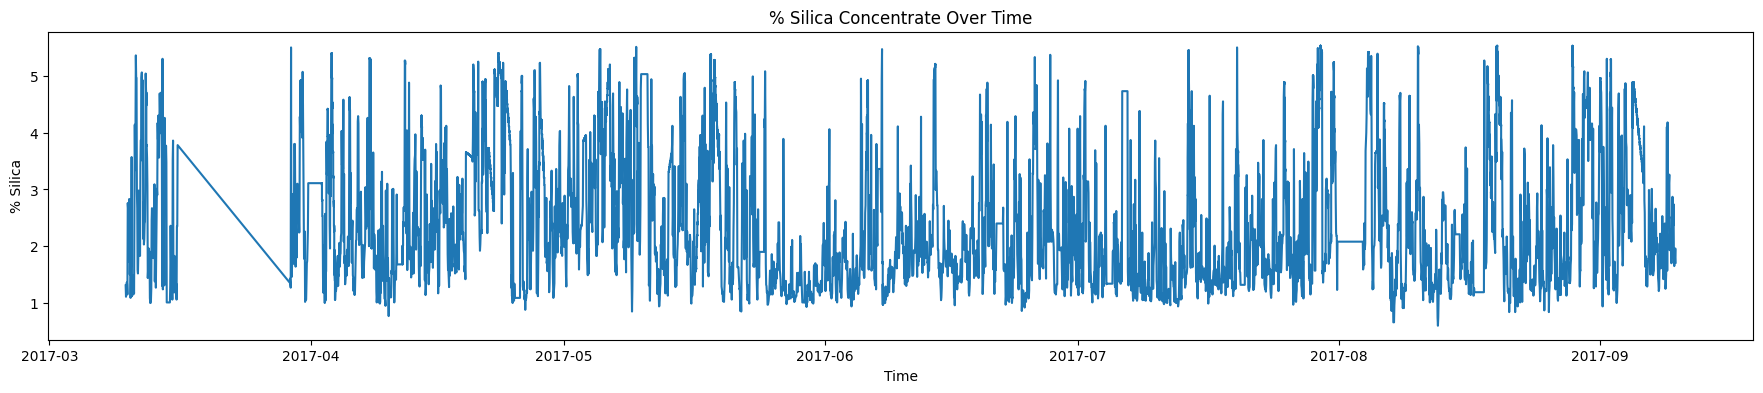

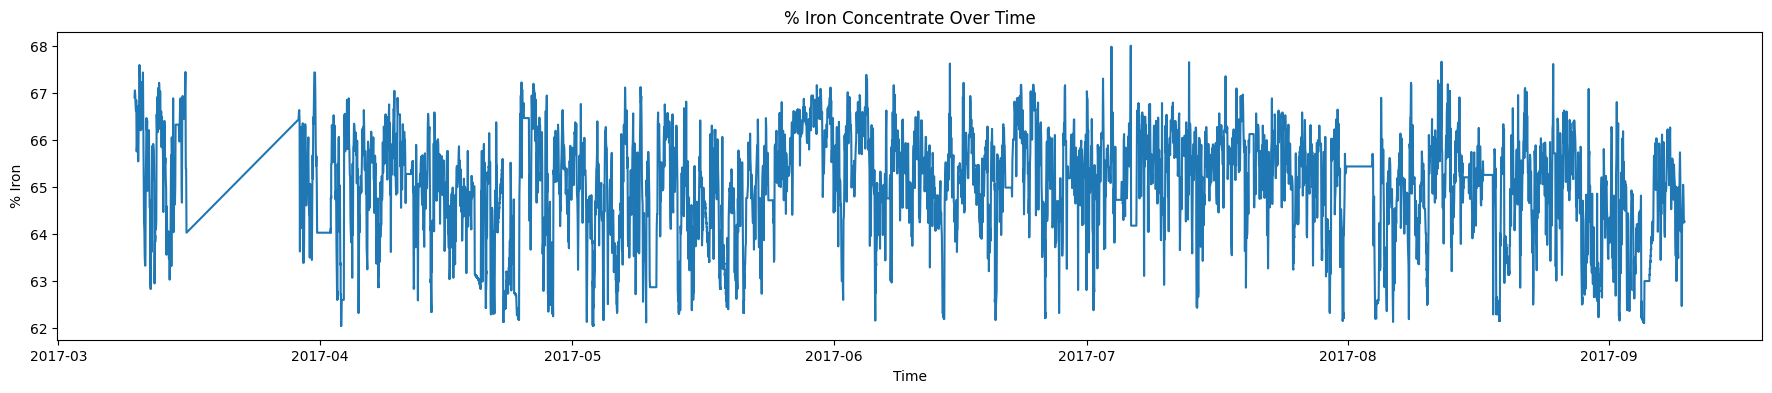

In [9]:
########### Visualize Missing Hour Range ###########
silica_over_time = df_mining['% Silica Concentrate']
plt.figure(figsize=(22,4))
plt.plot(silica_over_time.index, silica_over_time)
plt.title('% Silica Concentrate Over Time')
plt.xlabel('Time')
plt.ylabel('% Silica')
plt.show()

iron_over_time = df_mining['% Iron Concentrate']
plt.figure(figsize=(22,4))
plt.plot(iron_over_time.index, iron_over_time)
plt.title('% Iron Concentrate Over Time')
plt.xlabel('Time')
plt.ylabel('% Iron')
plt.show()

## 5. Reconstruct Timestamps for Continuous 20s and 1min Resolution Dataframes (no missing hours)

In [10]:
df_temp = df_mining.copy()

# Assign synthetic 20s timestamps within each hour
df_temp['hour'] = df_temp.index
df_temp['idx_in_hour'] = df_temp.groupby('hour').cumcount()  # 0..179
df_temp.index = df_temp['hour'] + pd.to_timedelta(df_temp['idx_in_hour'] * 20, unit='s')
df_temp = df_temp.drop(columns=['hour', 'idx_in_hour'])

# Reindex to full 20s grid (NaNs where data is missing)
full_20s_index = pd.date_range(df_temp.index.min(), df_temp.index.max(), freq='20s')
df_20s = df_temp.reindex(full_20s_index)
df_20s.index.name = 'date'

# Now 1-min resample
df_1min = df_20s.resample('1min').mean(numeric_only=True)

# Display resampled dataframes
with pd.option_context('display.max_columns', None):
    print('df_20s ', df_20s.shape, ':', sep='')
    display(df_20s)

    print('\ndf_1min ', df_1min.shape, ':', sep='')
    display(df_1min)

df_20s (794700, 23):


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.20,16.98,3019.53,557.434,395.713000,10.06640,1.74000,249.214,253.235,250.576,295.096,306.400,250.225,250.8840,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 01:00:20,55.20,16.98,3047.36,568.665,397.939000,10.06890,1.74000,249.917,254.487,250.049,295.096,306.400,250.422,251.1470,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
2017-03-10 01:00:40,55.20,16.98,3033.69,558.167,400.254000,10.06970,1.74000,250.203,252.136,249.895,295.096,306.400,249.983,248.9280,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31
2017-03-10 01:01:00,55.20,16.98,3193.07,596.588,399.507000,10.12170,1.74565,250.345,246.050,248.599,295.096,306.400,254.213,250.4880,457.171,381.078,447.533,457.598,462.853,429.902,395.663,66.91,1.31
2017-03-10 01:01:20,55.20,16.98,3079.10,564.697,396.533000,10.07050,1.74000,250.730,248.906,249.521,295.096,306.400,250.356,251.8730,444.384,443.269,460.449,439.920,451.588,433.539,425.458,66.91,1.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-09 23:58:20,49.75,23.20,1164.12,468.019,384.801000,9.61497,1.65310,300.355,292.865,298.625,298.717,297.395,362.464,308.1150,413.754,514.143,881.323,378.969,500.100,374.354,441.182,64.27,1.71
2017-09-09 23:58:40,49.75,23.20,3140.83,442.035,377.329286,9.61246,1.65466,297.070,302.897,299.707,301.535,302.507,358.209,355.2490,371.959,528.292,881.470,400.075,509.598,436.062,406.169,64.27,1.71
2017-09-09 23:59:00,49.75,23.20,3351.67,457.396,383.806000,9.62300,1.65668,299.268,296.670,302.990,300.185,296.825,344.677,306.7086,395.800,486.057,882.199,413.897,506.747,401.170,396.617,64.27,1.71



df_1min (264900, 23):


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.20,16.98,3033.526667,561.422000,397.968667,10.068333,1.740000,249.778000,253.286000,250.173333,295.096000,306.400000,250.210000,250.319667,454.092667,448.009000,439.447333,447.812667,478.754667,442.580667,458.897333,66.91,1.31
2017-03-10 01:01:00,55.20,16.98,3133.320000,575.917333,396.313333,10.087833,1.741883,250.462667,249.052667,249.067333,295.096000,306.400000,251.839667,251.946000,449.246667,422.972667,453.429333,442.948667,452.663000,436.005333,417.457333,66.91,1.31
2017-03-10 01:02:00,55.20,16.98,3147.593333,560.221333,394.804667,10.073000,1.740000,249.895000,252.312000,248.745000,295.096000,306.400000,248.848000,250.788667,446.118667,472.835000,460.469333,451.455333,444.921333,456.468667,453.781333,66.91,1.31
2017-03-10 01:03:00,55.20,16.98,3150.910000,563.314000,395.820333,10.072700,1.740000,249.323667,250.393000,250.744667,295.096000,306.400000,249.961000,248.979333,455.444333,430.997333,451.029667,453.344333,470.495000,445.903333,470.448667,66.91,1.31
2017-03-10 01:04:00,55.20,16.98,3473.763333,563.090333,393.799000,10.077933,1.740000,249.551000,251.176667,250.444667,295.096000,306.400000,249.558333,249.550667,438.878000,421.046333,438.098667,461.381000,479.312000,466.212667,470.940333,66.91,1.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-09 23:55:00,49.75,23.20,2806.093333,458.414667,385.657333,9.618350,1.654330,301.258000,304.429333,301.355000,300.653333,302.042667,354.626667,312.407333,401.856000,544.387333,881.265000,417.711667,484.265000,344.557000,358.246333,64.27,1.71
2017-09-09 23:56:00,49.75,23.20,2705.773333,469.490000,381.697000,9.620110,1.653930,302.417000,298.622000,299.887000,299.826000,298.789000,350.136333,301.185000,392.335000,530.782333,870.522333,424.584000,486.970000,456.613333,386.959333,64.27,1.71
2017-09-09 23:57:00,49.75,23.20,2698.383333,471.658667,385.001667,9.620220,1.653517,303.006333,302.687333,299.379000,299.852333,299.931667,335.469000,258.758000,400.854667,411.544667,868.005000,418.877667,502.453333,385.129000,425.453000,64.27,1.71


## 6. Compare 20s vs 1min Descriptive Statistics

In [11]:
with pd.option_context('display.max_columns', None):
    print("====== df_20s Statistics ======")
    display(df_20s.describe())
    print("NaN count:")
    display(df_20s.isna().sum().to_frame().T)

    print("\n====== df_1min Statistics ======")
    display(df_1min.describe())
    print("NaN count:")
    display(df_1min.isna().sum().to_frame().T)

====== df_20s Statistics ======


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.00000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000,737460.000000
mean,56.294730,14.651733,2869.141657,488.144983,397.578307,9.767642,1.680380,280.151564,277.159672,281.082091,299.447752,299.917876,292.071088,290.754463,520.244351,522.64937,531.352127,420.321189,425.252041,429.941619,421.021776,65.050084,2.326754
std,5.157721,6.807410,1215.198645,91.230297,9.699763,0.387007,0.069249,29.621299,30.149365,28.558306,2.572560,3.636617,30.217935,28.670253,131.014482,128.16452,150.841622,91.794023,84.535493,89.862011,84.891275,1.118652,1.125553
min,42.740000,1.310000,0.002026,241.669000,376.249000,8.753340,1.519820,175.510000,175.156000,176.469000,292.195000,286.295000,189.928000,185.962000,149.218000,210.75200,126.255000,162.201000,166.991000,155.841000,175.349000,62.050000,0.600000
25%,52.670000,8.940000,2076.320000,431.796750,394.263000,9.527360,1.647310,250.281000,250.457000,250.855000,298.262353,298.068010,262.474250,256.290750,416.978000,441.88400,411.326000,356.680000,357.654750,358.497750,356.772000,64.370000,1.440000
50%,56.080000,13.850000,3018.440000,504.394000,399.248714,9.798100,1.697600,299.344000,296.223000,298.696000,299.804990,299.887280,299.477000,299.011000,491.877000,495.95550,494.317000,411.975000,408.775000,424.666000,411.067000,65.210000,2.000000
75%,59.720000,19.600000,3727.722500,553.256000,402.968000,10.038000,1.728330,300.149000,300.690000,300.382000,300.638000,301.791647,303.061000,301.904000,594.113000,595.46400,601.249000,485.548250,484.329000,492.686000,476.466250,65.860000,3.010000
max,65.780000,33.400000,6300.230000,739.538000,418.641000,10.808100,1.853250,373.871000,375.992000,364.346000,305.871000,310.270000,370.910000,371.593000,862.274000,828.91900,886.822000,680.359000,675.644000,698.861000,659.902000,68.010000,5.530000


NaN count:


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240,57240



====== df_1min Statistics ======


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000,245820.000000
mean,56.294730,14.651733,2869.141657,488.144983,397.578307,9.767642,1.680380,280.151564,277.159672,281.082091,299.447752,299.917876,292.071088,290.754463,520.244351,522.649370,531.352127,420.321189,425.252041,429.941619,421.021776,65.050084,2.326754
std,5.157728,6.807419,1139.005235,89.653817,9.271543,0.386145,0.068520,29.585554,29.835665,28.512739,2.486759,3.487819,29.880087,27.975203,128.795679,125.192738,148.330710,87.244695,81.503747,83.213622,80.843959,1.118604,1.125487
min,42.740000,1.310000,0.317815,241.699632,376.302577,8.753370,1.519832,175.752108,175.971531,176.471917,292.774049,286.969954,192.333667,186.074077,149.599000,211.389000,126.400047,162.335222,167.165240,162.029308,176.293000,62.050000,0.600000
25%,52.670000,8.940000,2088.325000,432.358333,395.720667,9.528382,1.647540,250.237333,250.331917,250.544333,298.780890,298.623333,262.971917,266.168583,412.985833,443.561167,408.959500,356.323000,356.566917,358.397750,356.568833,64.370000,1.440000
50%,56.080000,13.850000,2958.735000,503.979000,399.436667,9.798357,1.697317,299.488000,297.564333,299.196833,299.821667,299.907667,299.632000,299.402000,494.187167,497.278167,496.289500,408.778500,406.977333,418.674833,408.355500,65.210000,2.000000
75%,59.720000,19.600000,3679.924167,553.055667,402.176667,10.037067,1.727574,300.089333,300.395333,300.237667,300.391333,301.169000,301.396000,301.097333,595.887167,596.412417,600.850750,486.913417,486.422583,490.436500,475.375750,65.860000,3.010000
max,65.780000,33.400000,6294.400704,739.422405,418.617879,10.808063,1.853218,369.492335,367.523667,356.775270,305.843000,309.728709,368.167724,369.395000,862.175398,828.541733,886.820204,679.943933,675.441295,698.615483,659.341130,68.010000,5.530000


NaN count:


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080,19080


## 7. Compare 20s vs 1min Correlations

In this section we can see that 20sec vs 1min correlation patterns are very similar

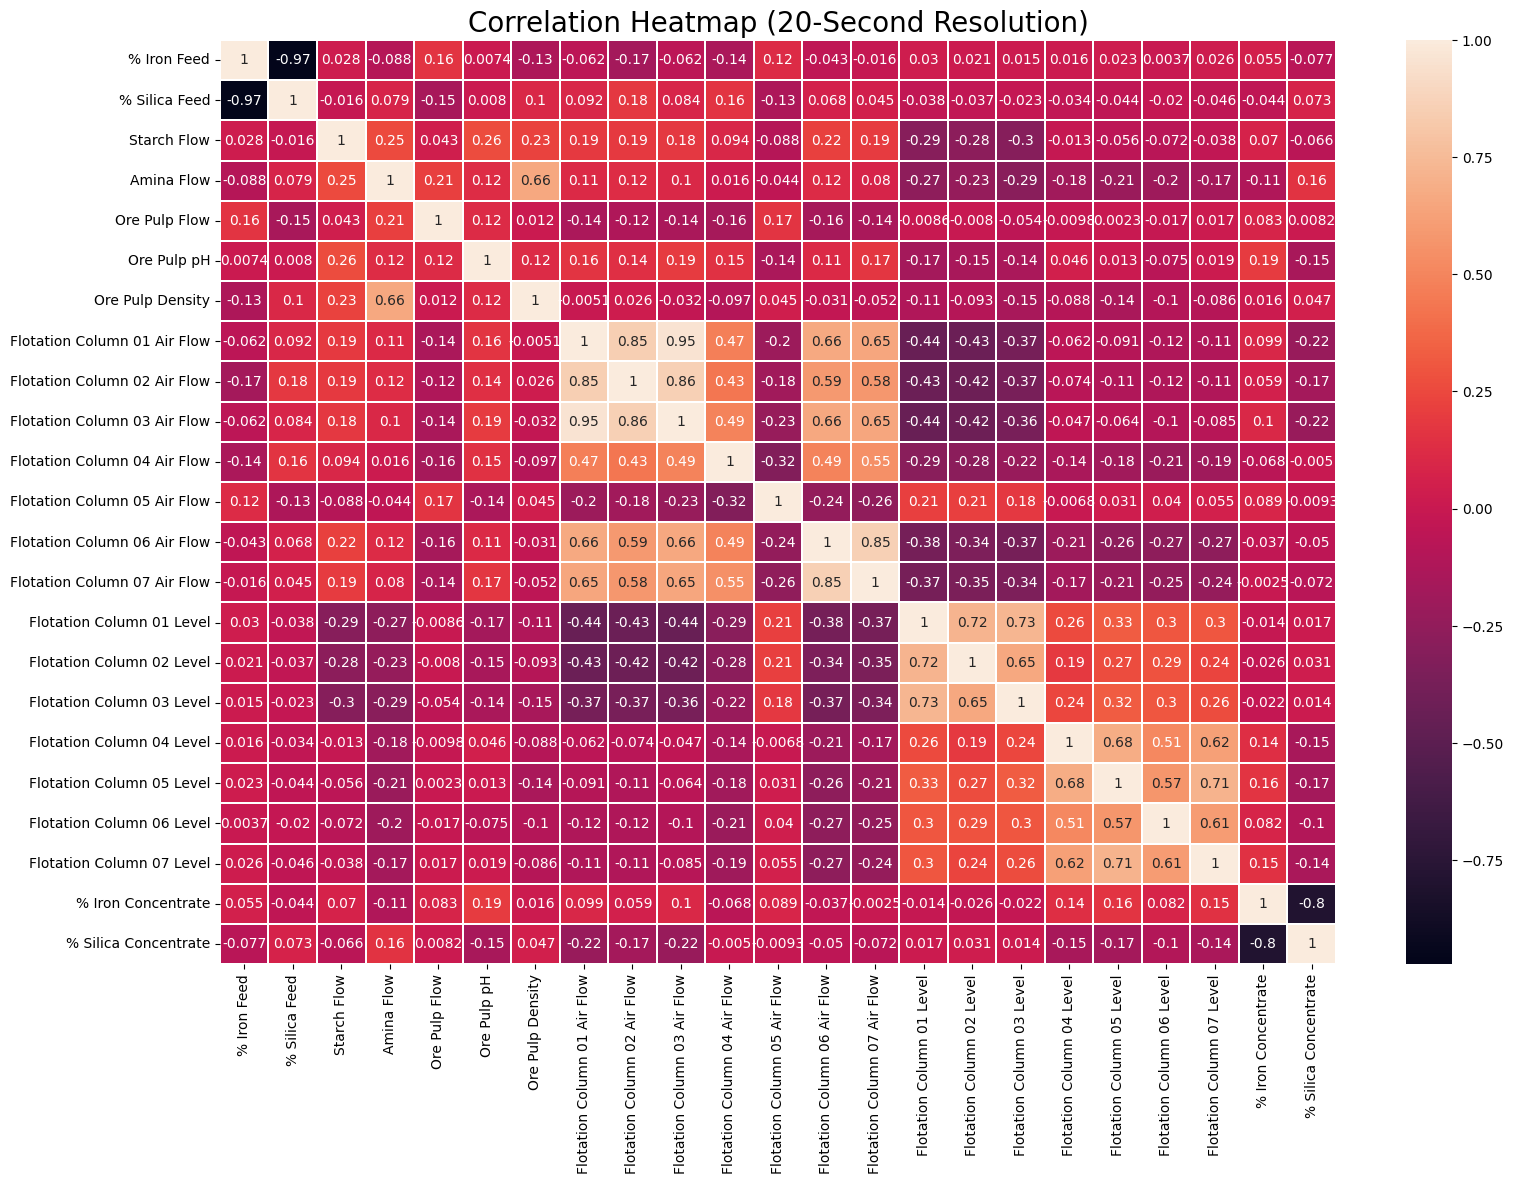

In [12]:
# --- 20-second correlations ---
plt.figure(figsize=(18,12))
sns.heatmap(df_20s.corr(), annot=True, linewidths=0.003)
plt.title('Correlation Heatmap (20-Second Resolution)', fontsize=20)
plt.show()

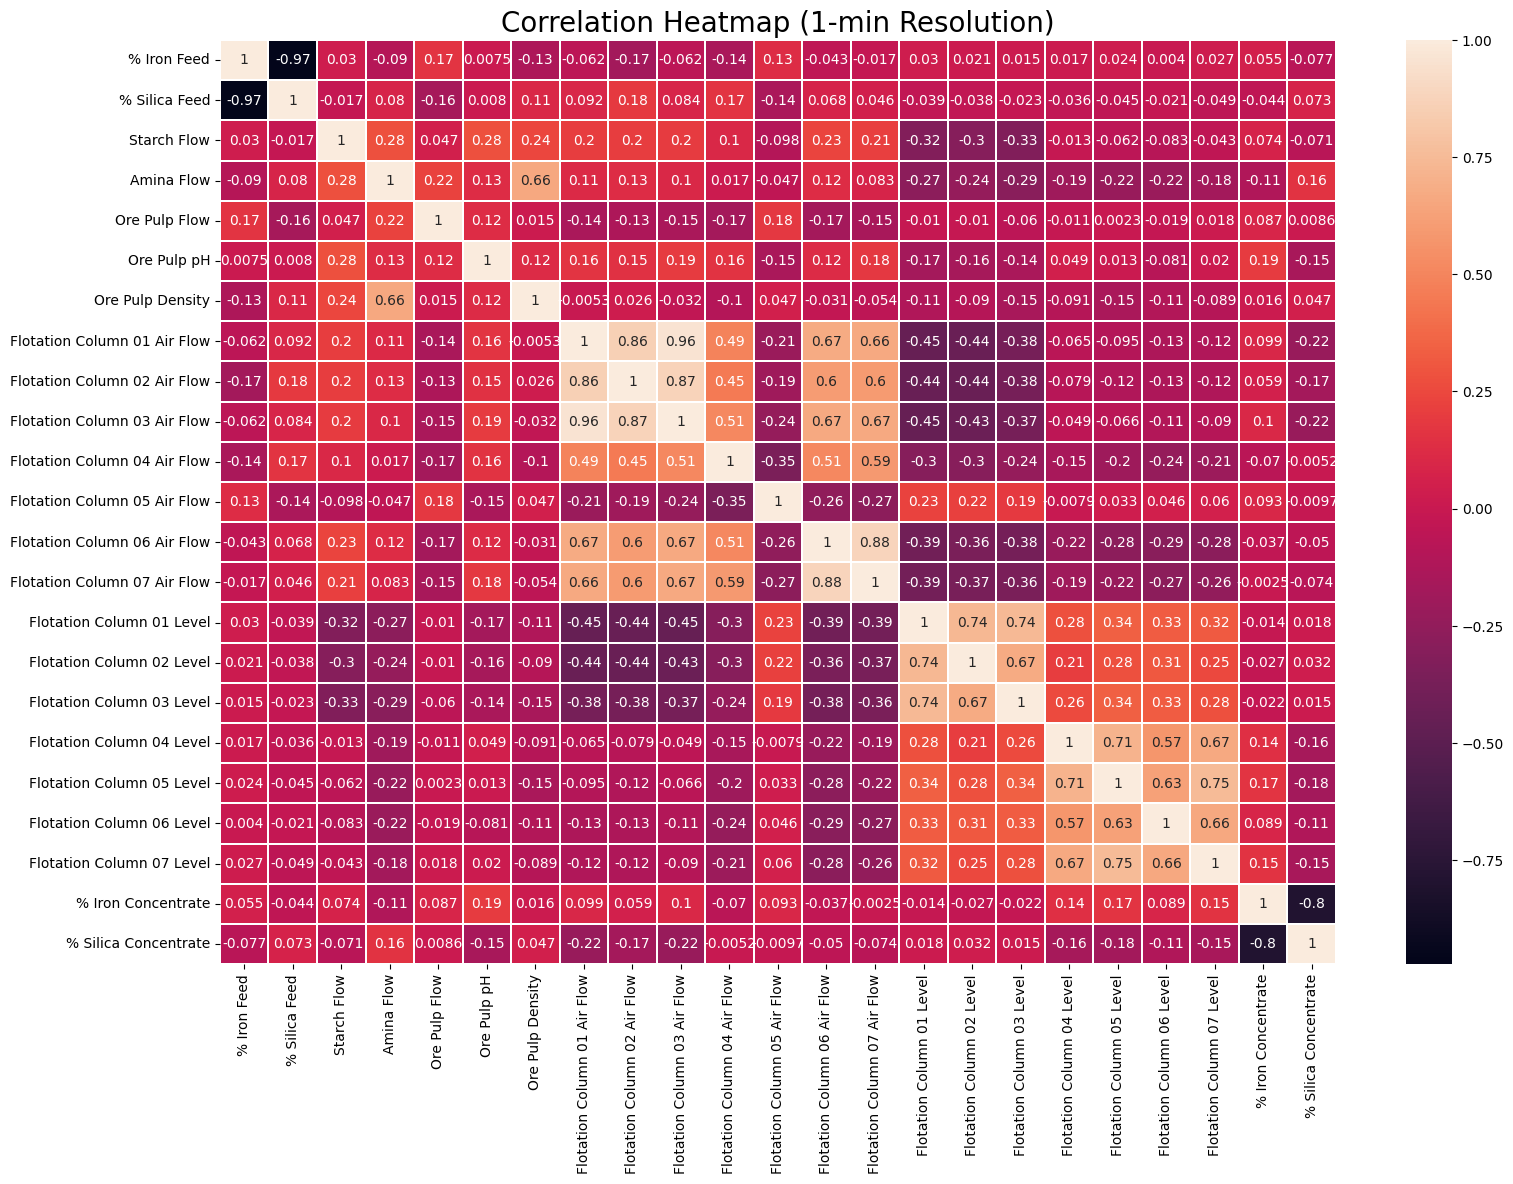

In [13]:
# --- 1-minute correlations ---
plt.figure(figsize=(18,12))
sns.heatmap(df_1min.corr(), annot=True, linewidths=0.003)
plt.title('Correlation Heatmap (1-min Resolution)', fontsize=20)
plt.show()

## 8. Target (% Silica Concentrate) Continuity Assesment
**Should see a visible gap this time because NaN has been filled in for missing timestamps**

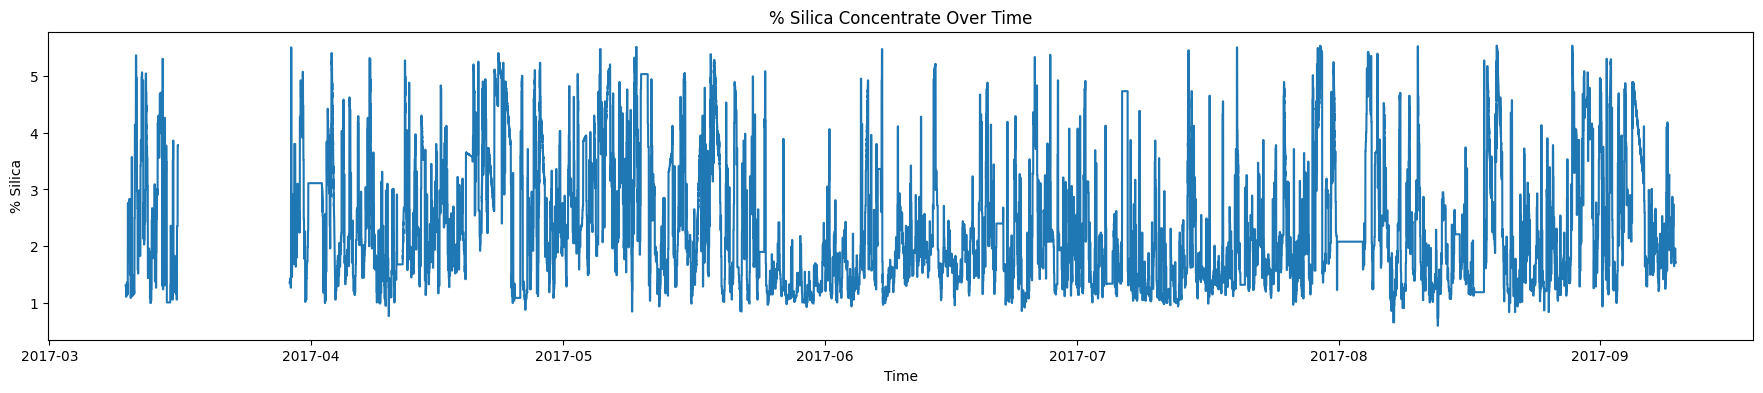

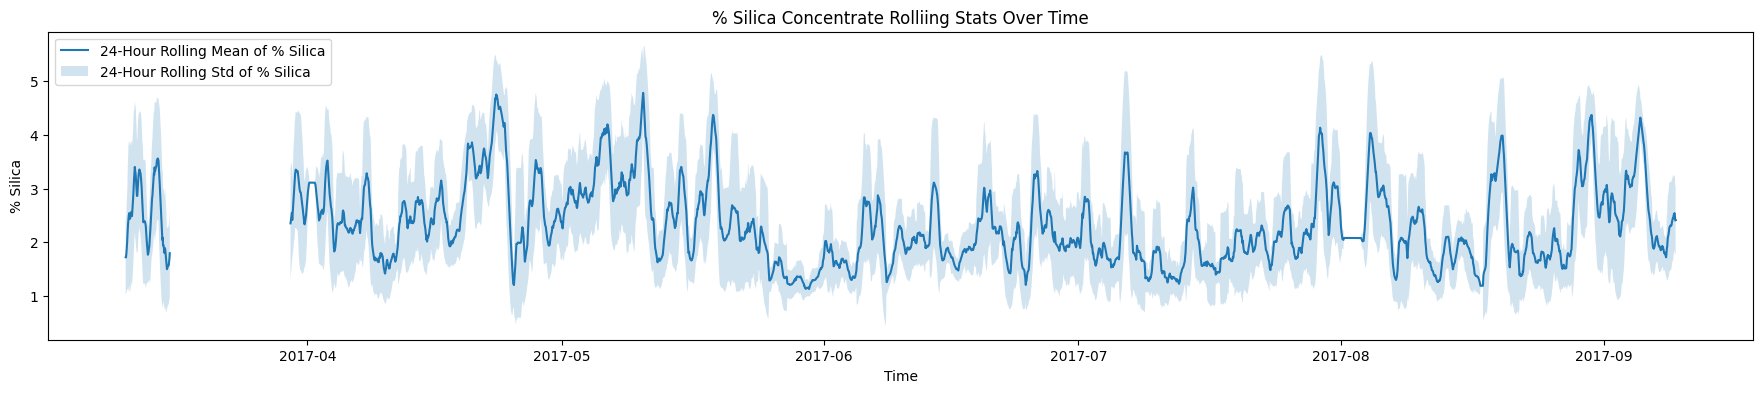

In [14]:
# Plot time trend
silica_over_time = df_1min['% Silica Concentrate']
plt.figure(figsize=(22,4))
plt.plot(silica_over_time.index, silica_over_time)
plt.title('% Silica Concentrate Over Time')
plt.xlabel('Time')
plt.ylabel('% Silica')
plt.show()

# Apply Rolling Statistics
rolling_window = 60*24 # one day rolling window
silica_rolling_mean = silica_over_time.rolling(window=rolling_window, center=True).mean()
silica_rolling_std = silica_over_time.rolling(window=rolling_window, center=True).std()

# Plot time trend will rolling stats
plt.figure(figsize=(22,4))
plt.plot(silica_rolling_mean.index, silica_rolling_mean, label='24-Hour Rolling Mean of % Silica')
plt.fill_between(silica_rolling_std.index, silica_rolling_mean - silica_rolling_std, silica_rolling_mean + silica_rolling_std, alpha=0.2, label='24-Hour Rolling Std of % Silica')
plt.title('% Silica Concentrate Rolliing Stats Over Time')
plt.xlabel('Time')
plt.ylabel('% Silica')
plt.legend()
plt.show()

## 9. Frequency Distributions

In [15]:
# # Select only numeric columns (ignores timestamp + categorical)
# num_cols = df_mining.select_dtypes(include=[np.number]).columns

# # Layout (adjust as needed)
# n_cols = 4
# n_rows = int(np.ceil(len(num_cols) / n_cols))

# plt.figure(figsize=(20, 4 * n_rows))

# for i, col in enumerate(num_cols, 1):
#     plt.subplot(n_rows, n_cols, i)
#     sns.histplot(df_mining[col], bins=30, kde=True)
#     # plt.hist(df_mining[col], bins=50, alpha=0.7)
#     plt.title(col, fontsize=10)
#     plt.tight_layout()

# plt.show()

---
# III. Baseline Model
This section trains and test our baseline (Linear Regression) model

## 1. Train + Test Split Helpers

In [16]:
# Training on first 85% of time series and test on rest 15%
def train_85_test_15_split(df, debug=False):
    # 1. Prepare data
    df_ml = df.copy()
    df_ml = df_ml.dropna()
    X = df_ml.drop(columns=['% Iron Concentrate', '% Silica Concentrate'])
    y = df_ml['% Silica Concentrate']

    # 2. Chronological 85/15 split
    split_idx = int(len(df_ml) * 0.85)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # 3. Dump trian/test data if debug mode
    if debug:
        with pd.option_context('display.max_columns', None):
            print('X_train ', X_train.shape, ':', sep='')
            display(X_train)

            print('y_train ', y_train.shape, ':', sep='')
            display(y_train.to_frame().T)

            print('\nX_test ', X_test.shape, ':', sep='')
            display(X_test)

            print('y_test ', y_test.shape, ':', sep='')
            display(y_test.to_frame().T)

    return X_train, y_train, X_test, y_test

# Training on first row of every hour block (as recommended by Professor & TA)
def train_1_test_59_split(df, debug=False):
    # 1. Prepare data
    df_ml = df.copy()
    df_ml = df_ml.dropna()
    X = df_ml.drop(columns=['% Iron Concentrate', '% Silica Concentrate'])
    y = df_ml['% Silica Concentrate']

    if len(df_ml) % 60 != 0:
        print(f"⚠️ Warning: Dataframe length ({len(df_ml)}) is not divisible by 60. "
              "Last incomplete block will still be handled.")

    # 2. Select training rows: first row of every 60-row block
    train_idx = df_ml.iloc[::60].index
    X_train, y_train = X.loc[train_idx], y.loc[train_idx]

    # 3. Select test rows: all non-training rows
    test_mask = ~df_ml.index.isin(train_idx)
    X_test, y_test = X.loc[test_mask], y.loc[test_mask]

    # 4. Dump trian/test data if debug mode
    if debug:
        with pd.option_context('display.max_columns', None):
            print('X_train ', X_train.shape, ':', sep='')
            display(X_train)

            print('y_train ', y_train.shape, ':', sep='')
            display(y_train.to_frame().T)

            print('\nX_test ', X_test.shape, ':', sep='')
            display(X_test)

            print('y_test ', y_test.shape, ':', sep='')
            display(y_test.to_frame().T)

    return X_train, y_train, X_test, y_test

## 2. Baselien Training & Results

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error

def train_test_on_baseline_model(df, splitter, debug=False):
    # -----------------------------
    # 1. Prepare train/test data
    # -----------------------------
    X_train, y_train, X_test, y_test = splitter(df, debug)

    # -----------------------------
    # 2. Fit baseline model
    # -----------------------------
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)  # Predictions

    # -----------------------------
    # 3. Metrics (scale-independent except mae)
    # -----------------------------
    mape  = mean_absolute_percentage_error(y_test, y_pred)
    r2    = r2_score(y_test, y_pred)
    mae   = mean_absolute_error(y_test, y_pred)

    print("\n===================================")
    print("Baseline Linear Regression Results:")
    print(f"MAPE: {mape * 100:.2f}%")
    print(f"R²:   {r2:.4f}")
    print(f"MAE:  {mae:.4f}")
    print("===================================")

train_test_on_baseline_model(df_1min, train_85_test_15_split, False)


Baseline Linear Regression Results:
MAPE: 37.57%
R²:   0.0298
MAE:  0.9031


---
# IV. Feature Engineering

This section covers addition of new features in order to help predictions. Both Hour-Level and Minute-Level features were added very carefully without introducing any data leaks. Date leaking is very easy with this dataset because there are reapeating targets for many rows. We also added calendar features

## 1. Hour-level: Lag (1h-24h) and Past Value (7d)

In [18]:
df_w_lag_and_pv = df_1min.copy()

# 1. Lag Features for past 24 hrs
for i in range(1, 25):
    df_w_lag_and_pv[f'% Iron Concentrate {i}h ago'] = df_w_lag_and_pv['% Iron Concentrate'].shift(i*60)

for i in range(1, 25):
    df_w_lag_and_pv[f'% Silica Concentrate {i}h ago'] = df_w_lag_and_pv['% Silica Concentrate'].shift(i*60)

# 2. Past Value Feature (7 days ago)
df_w_lag_and_pv['% Iron Concentrate 7d ago'] = df_w_lag_and_pv['% Iron Concentrate'].shift(7*24*60)
df_w_lag_and_pv['% Silica Concentrate 7d ago'] = df_w_lag_and_pv['% Silica Concentrate'].shift(7*24*60)

with pd.option_context('display.max_columns', None):
    print('df_w_lag_and_pv ', df_w_lag_and_pv.shape, ':', sep='')
    display(df_w_lag_and_pv[::60]) # Show every 60th row (one row per hour)

df_w_lag_and_pv (264900, 73):


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate,% Iron Concentrate 1h ago,% Iron Concentrate 2h ago,% Iron Concentrate 3h ago,% Iron Concentrate 4h ago,% Iron Concentrate 5h ago,% Iron Concentrate 6h ago,% Iron Concentrate 7h ago,% Iron Concentrate 8h ago,% Iron Concentrate 9h ago,% Iron Concentrate 10h ago,% Iron Concentrate 11h ago,% Iron Concentrate 12h ago,% Iron Concentrate 13h ago,% Iron Concentrate 14h ago,% Iron Concentrate 15h ago,% Iron Concentrate 16h ago,% Iron Concentrate 17h ago,% Iron Concentrate 18h ago,% Iron Concentrate 19h ago,% Iron Concentrate 20h ago,% Iron Concentrate 21h ago,% Iron Concentrate 22h ago,% Iron Concentrate 23h ago,% Iron Concentrate 24h ago,% Silica Concentrate 1h ago,% Silica Concentrate 2h ago,% Silica Concentrate 3h ago,% Silica Concentrate 4h ago,% Silica Concentrate 5h ago,% Silica Concentrate 6h ago,% Silica Concentrate 7h ago,% Silica Concentrate 8h ago,% Silica Concentrate 9h ago,% Silica Concentrate 10h ago,% Silica Concentrate 11h ago,% Silica Concentrate 12h ago,% Silica Concentrate 13h ago,% Silica Concentrate 14h ago,% Silica Concentrate 15h ago,% Silica Concentrate 16h ago,% Silica Concentrate 17h ago,% Silica Concentrate 18h ago,% Silica Concentrate 19h ago,% Silica Concentrate 20h ago,% Silica Concentrate 21h ago,% Silica Concentrate 22h ago,% Silica Concentrate 23h ago,% Silica Concentrate 24h ago,% Iron Concentrate 7d ago,% Silica Concentrate 7d ago
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.20,16.98,3033.526667,561.422000,397.968667,10.068333,1.740000,249.778000,253.286000,250.173333,295.096000,306.400000,250.210000,250.319667,454.092667,448.009000,439.447333,447.812667,478.754667,442.580667,458.897333,66.91,1.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-10 02:00:00,55.20,16.98,3086.230000,534.607000,396.655333,10.146633,1.661703,250.191667,250.279667,249.854667,295.096000,306.400000,249.869333,250.166000,448.930000,493.687333,444.242333,448.098667,443.617667,446.116333,440.781333,67.06,1.11,66.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-10 03:00:00,55.20,16.98,3736.990000,580.668000,399.077000,10.089700,1.713220,249.979000,251.627333,251.473333,295.096000,306.400000,250.125667,251.026667,452.491667,440.588333,440.344333,447.277333,461.196000,454.527333,468.791000,66.97,1.27,67.06,66.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.11,1.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-10 04:00:00,55.20,16.98,3176.563333,582.031333,400.981333,9.948473,1.720000,248.386333,248.269000,249.364000,295.096000,306.400000,249.078333,249.433333,454.318333,456.653333,457.378667,447.026333,469.287333,471.411333,492.499667,66.75,1.36,66.97,67.06,66.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.27,1.11,1.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-10 05:00:00,55.20,16.98,2774.524000,612.317000,398.112333,9.842130,1.759990,248.531333,250.830000,250.370000,295.096000,306.400000,245.690667,248.338333,559.557333,556.059000,546.090000,538.702000,54

## 2. Hour-level: Rolling Mean and Std

In [19]:
df_w_hr_stat = df_w_lag_and_pv.copy()

# --- Build hourly series for Iron and Silica ---
iron_hourly   = df_w_hr_stat['% Iron Concentrate'].groupby(df_w_hr_stat.index.floor('h')).first()
silica_hourly = df_w_hr_stat['% Silica Concentrate'].groupby(df_w_hr_stat.index.floor('h')).first()
hour_index = df_w_hr_stat.index.floor('h') # Helper: map hourly rolling results back to the minute index

# Rolling features for Iron
for hr in [6, 24]:
    roll_mean = iron_hourly.rolling(window=hr, min_periods=hr).mean().shift(1)
    roll_std  = iron_hourly.rolling(window=hr, min_periods=hr).std().shift(1)

    df_w_hr_stat[f'% Iron Conc rolling mean {hr}h'] = hour_index.map(roll_mean)
    df_w_hr_stat[f'% Iron Conc rolling std {hr}h']  = hour_index.map(roll_std)

# Rolling features for Silica
for hr in [6, 12, 24]:
    roll_mean = silica_hourly.rolling(window=hr, min_periods=hr).mean().shift(1)
    roll_std  = silica_hourly.rolling(window=hr, min_periods=hr).std().shift(1)

    df_w_hr_stat[f'% Silica Conc rolling mean {hr}h'] = hour_index.map(roll_mean)
    df_w_hr_stat[f'% Silica Conc rolling std {hr}h']  = hour_index.map(roll_std)


print('df_w_hr_stat ', df_w_hr_stat.shape, ':', sep='')
with pd.option_context('display.max_columns', None, 'display.max_rows', None):
    display(df_w_hr_stat.iloc[-10:, -12:]) # Show last 10 rows and last 12 cols

with pd.option_context('display.max_columns', None):
    display(df_w_hr_stat.iloc[::60, -12:]) # Show every 60th row (one row per hour) and only last 10 cols
    # display(df_w_hr_stat[::60]) # Show every 60th row (one row per hour)

df_w_hr_stat (264900, 83):


,% Iron Concentrate 7d ago,% Silica Concentrate 7d ago,% Iron Conc rolling mean 6h,% Iron Conc rolling std 6h,% Iron Conc rolling mean 24h,% Iron Conc rolling std 24h,% Silica Conc rolling mean 6h,% Silica Conc rolling std 6h,% Silica Conc rolling mean 12h,% Silica Conc rolling std 12h,% Silica Conc rolling mean 24h,% Silica Conc rolling std 24h
date,,,,,,,,,,,,
2017-09-09 23:50:00,65.01,1.0,64.548333,0.347817,64.3425,0.752192,1.948333,0.402165,2.170833,0.440608,2.404583,0.638538
2017-09-09 23:51:00,65.01,1.0,64.548333,0.347817,64.3425,0.752192,1.948333,0.402165,2.170833,0.440608,2.404583,0.638538
2017-09-09 23:52:00,65.01,1.0,64.548333,0.347817,64.3425,0.752192,1.948333,0.402165,2.170833,0.440608,2.404583,0.638538
2017-09-09 23:53:00,65.01,1.0,64.548333,0.347817,64.3425,0.752192,1.948333,0.402165,2.170833,0.440608,2.404583,0.638538
2017-09-09 23:54:00,65.01,1.0,64.548333,0.347817,64.3425,0.752192,1.948333,0.402165,2.170833,0.440608,2.404583,0.638538
2017-09-09 23:55:00,65.01,1.0,64.548333,0.347817,64.3425,0.752192,1.948333,0.402165,2.170833,0.440608,2.404583,0.638538
2017-09-09 23:56:00,65.01,1.0,64.548333,0.347817,64.3425,0.752192,1.948333,0.402165,2.170833,0.440608,2.404583,0.638538
2017-09-09 23:57:00,65.01,1.0,64.548333,0.347817,64.3425,0.752192,1.948333,0.402165,2.170833,0.440608,2.404583,0.638538
2017-09-09 23:58:00,65.01,1.0,64.548333,0.347817,64.3425,0.752192,1.948333,0.402165,2.170833,0.440608,2.404583,0.638538


,% Iron Concentrate 7d ago,% Silica Concentrate 7d ago,% Iron Conc rolling mean 6h,% Iron Conc rolling std 6h,% Iron Conc rolling mean 24h,% Iron Conc rolling std 24h,% Silica Conc rolling mean 6h,% Silica Conc rolling std 6h,% Silica Conc rolling mean 12h,% Silica Conc rolling std 12h,% Silica Conc rolling mean 24h,% Silica Conc rolling std 24h
date,,,,,,,,,,,,
2017-03-10 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-10 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-10 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-10 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-10 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-09 19:00:00,64.54,1.51,64.070000,0.801973,64.303333,0.779758,2.451667,0.361409,2.323333,0.333203,2.519167,0.739618
2017-09-09 20:00:00,64.80,1.41,64.156667,0.885385,64.300417,0.776696,2.318333,0.487665,2.275000,0.385876,2.532500,0.719869
2017-09-09 21:00:00,64.50,1.42,64.245000,0.927960,64.297083,0.774133,2.125000,0.453993,2.238333,0.418370,2.541250,0.707951


## 3. Minute Level: Short-term dynamics features

In [20]:
df_w_min_stat = df_w_hr_stat.copy()

df_w_min_stat['pH_diff_1min'] = df_w_min_stat['Ore Pulp pH'].diff(1)
df_w_min_stat['AirFlow07_diff_1min'] = df_w_min_stat['Flotation Column 07 Air Flow'].diff(1)

df_w_min_stat['Amina_to_pulp'] = df_w_min_stat['Amina Flow'] / df_w_min_stat['Ore Pulp Flow']
df_w_min_stat['Starch_to_pulp'] = df_w_min_stat['Starch Flow'] / df_w_min_stat['Ore Pulp Flow']

df_w_min_stat['AirFlow_total'] = df_w_min_stat.filter(like='Air Flow').sum(axis=1)
df_w_min_stat['Level_total'] = df_w_min_stat.filter(like='Level').sum(axis=1)
for col in ['AirFlow_total', 'Level_total']:
    df_w_min_stat[f'{col}_roll_mean_10m'] = (
        df_w_min_stat[col].rolling(window=10, min_periods=10).mean().shift(1)
    )
    df_w_min_stat[f'{col}_roll_std_10m'] = (
        df_w_min_stat[col].rolling(window=10, min_periods=10).std().shift(1)
    )


print('df_w_min_stat ', df_w_min_stat.shape, ':', sep='')
with pd.option_context('display.max_columns', None):
    display(df_w_min_stat.iloc[::60, -10:])

df_w_min_stat (264900, 93):


,pH_diff_1min,AirFlow07_diff_1min,Amina_to_pulp,Starch_to_pulp,AirFlow_total,Level_total,AirFlow_total_roll_mean_10m,AirFlow_total_roll_std_10m,Level_total_roll_mean_10m,Level_total_roll_std_10m
date,,,,,,,,,,
2017-03-10 01:00:00,NaN,NaN,1.410719,7.622526,1855.263000,3169.594333,NaN,NaN,NaN,NaN
2017-03-10 02:00:00,-0.013067,0.820333,1.347787,7.780634,1851.857333,3165.473667,1851.062367,3.693806,3193.351283,68.044100
2017-03-10 03:00:00,0.005233,1.512333,1.455027,9.364083,1855.728000,3165.216000,1850.021467,1.541877,3187.955267,37.002531
2017-03-10 04:00:00,-0.012813,-0.454333,1.451517,7.921973,1846.027000,3248.575000,1849.080000,4.138587,3171.159500,45.444563
2017-03-10 05:00:00,-0.001620,-2.223333,1.538051,6.969199,1845.256333,3829.212667,1851.755500,3.292644,3809.533333,143.195098
...,...,...,...,...,...,...,...,...,...,...
2017-09-09 19:00:00,-0.088837,-0.740333,1.278126,6.467090,2097.801667,3072.157667,2101.092500,5.783453,2897.585600,177.335971
2017-09-09 20:00:00,0.032033,-5.656583,1.271135,11.224732,2161.025667,3100.444667,2139.546731,29.610481,2999.005567,64.623031
2017-09-09 21:00:00,0.086757,63.355667,1.371521,5.361017,2183.782333,2925.233667,2142.638598,19.693811,2986.482100,85.467956


## 4. Calendar Features

In [21]:
df_w_hr_and_day = df_w_min_stat.copy()

df_w_hr_and_day['day_of_week'] = df_w_hr_and_day.index.dayofweek
df_w_hr_and_day['hour_of_day'] = df_w_hr_and_day.index.hour

print('df_w_hr_and_day ', df_w_hr_and_day.shape, ':', sep='')
with pd.option_context('display.max_columns', None):
    display(df_w_hr_and_day.iloc[::60, -5:]) # Show every 60th row (one row per hour) and only last 5 cols

df_w_hr_and_day (264900, 95):


,AirFlow_total_roll_std_10m,Level_total_roll_mean_10m,Level_total_roll_std_10m,day_of_week,hour_of_day
date,,,,,
2017-03-10 01:00:00,NaN,NaN,NaN,4,1
2017-03-10 02:00:00,3.693806,3193.351283,68.044100,4,2
2017-03-10 03:00:00,1.541877,3187.955267,37.002531,4,3
2017-03-10 04:00:00,4.138587,3171.159500,45.444563,4,4
2017-03-10 05:00:00,3.292644,3809.533333,143.195098,4,5
...,...,...,...,...,...
2017-09-09 19:00:00,5.783453,2897.585600,177.335971,5,19
2017-09-09 20:00:00,29.610481,2999.005567,64.623031,5,20
2017-09-09 21:00:00,19.693811,2986.482100,85.467956,5,21


## 5. Make copy of all features

In [22]:
df_all_features = df_w_hr_and_day.copy()

---
# V. ML Pipeline for Hyperparameter Grid Search

Elasticnet, Lightgbm and Catboost were used here because they don't reequire consistent temporal structure and are able to treat every row independently (this includes freature engineered entries in the row for temporal context)

## 1. Build models + param grids

In [23]:
class CatBoostRegressorSK(_CatBoostRegressor, BaseEstimator, RegressorMixin):
    """Thin sklearn-compatible wrapper around CatBoostRegressor."""
    pass

# ---------------------------------------------------
# Helper: build models + param grids
# ---------------------------------------------------
def make_models():
    """Define models and their hyperparameter grids."""
    models = []

    ################### ElasticNet (with scaling) ###################
    elasticnet_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(max_iter=5000, random_state=42)),
    ])
    elasticnet_params = {
        "model__alpha":   [0.01, 0.05, 0.1, 0.5, 1.0],
        "model__l1_ratio": [0.1, 0.5, 0.9],
    }
    models.append(("ElasticNet", elasticnet_pipeline, elasticnet_params))

    ################### CatBoost (no scaling needed) ###################
    cat = CatBoostRegressorSK(
        loss_function="MAE",   # robust, works well
        random_seed=42,
        verbose=False,
        task_type="GPU",       # <- use GPU (if available)
        # devices="0",         # optional, if you want to specify GPU id
    )
    cat_params = {
        "depth":        [6, 8],
        "learning_rate":[0.03, 0.1],
        "n_estimators": [300, 700],
        "l2_leaf_reg":  [1, 3],
    }
    # Below are the parameters for the best performing CatBoost model after conducting CV grid search on
    # both 85-15 and 1-59 train/test splits using cat_params dictionary
    cat_params_best = {"depth": [6], "learning_rate": [0.03], "n_estimators": [300], "l2_leaf_reg": [3]}
    models.append(("CatBoost", cat, cat_params_best))

    ################### LightGBM (no scaling needed) ###################
    lgbm = LGBMRegressor(
        objective="regression",
        random_state=42,
        n_jobs=-1,
        # device_type="gpu",   # <- can't use GPU on JupyterHub, Exhausted all options
    )
    lgbm_params_48_fits = {
        "num_leaves":    [31, 63],
        "learning_rate": [0.05, 0.1],
        "n_estimators":  [200, 500],
        "max_depth":     [-1, 7],
    }
    lgbm_params_12_fits = {
        "num_leaves":    [31, 63],
        "learning_rate": [0.05],
        "n_estimators":  [300, 500],
    }
    # Below are the parameters for the best performing CatBoost model after conducting CV grid search on
    # both 85-15 and 1-59 train/test splits using lgbm_params dictionary
    lgbm_params_best = {"num_leaves":[31],"learning_rate":[0.05],"n_estimators":[500]}
    # models.append(("LightGBM", lgbm, lgbm_params_best))

    return models

## 2. Hyperparameter search + evaluation

In [24]:
# ---------------------------------------------------
# Helper: run hyperparameter search + evaluation
# ---------------------------------------------------
def tune_and_evaluate_models(models, X_train, y_train, X_test, y_test, folds=3, n_jobs=2):
    """
    Run GridSearchCV for each model, evaluate on test set, and return results + summary.
    """
    results = []

    # Time-series CV and MAPE scorer
    tscv = TimeSeriesSplit(n_splits=folds)
    mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

    for name, estimator, param_grid in tqdm(models, desc="Models"):
        print(f"\n===== Tuning {name} =====")

        timer = time.time()  # <<< start timing tuning+training (seconds)

        search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=mape_scorer,      # using -1*MAPE for scoring the lower MAPE as the better one
            cv=tscv,
            n_jobs=n_jobs,
            verbose=1
        )

        # Tune + train on full train set
        search.fit(X_train, y_train)
        timer = time.time() - timer   # <<< stop timing tuning+training (seconds)
        tune_train_time = time.strftime("%M:%S", time.gmtime(timer))

        best_model = search.best_estimator_
        print(f"Best params for {name}: {search.best_params_}")

        # Evaluate on test set
        y_pred = best_model.predict(X_test)

        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)
        mae  = mean_absolute_error(y_test, y_pred)

        print(f"{name} Test MAPE: {mape:.4f}")
        print(f"{name} Test R²:   {r2:.4f}")
        print(f"{name} Test MAE:  {mae:.4f}")
        print(f"{name} Time:      {tune_train_time}")

        results.append({
            "model": name,
            "best_params": search.best_params_,
            "test_MAPE": mape,
            "test_R2": r2,
            "test_MAE": mae,
            "best_estimator": best_model,
            "tune_train_time": tune_train_time,
            "folds": folds,
        })

    # Build comparison table (without estimator objects)
    summary = pd.DataFrame([
        {k: v for k, v in r.items() if k != "best_estimator"}
        for r in results
    ])

    return results, summary



## 3. Model Comparisons Method

In [25]:
# ---------------------------------------------------
# Orchestrator: one call
# ---------------------------------------------------
def run_model_comparison(df_features, split_func, folds=3, n_jobs=2, debug=True):
    """
    High-level runner:
    - prepares train/test with `split_func`
    - builds models
    - tunes & evaluates them
    - returns (results, summary)
    """
    # 1) Prep train / test using provided function
    X_train, y_train, X_test, y_test = split_func(df_features)
    if debug:
        print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)

    # 2) Build model list
    models = make_models()

    # 3) Tune + evaluate
    results, summary = tune_and_evaluate_models(
        models=models,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        folds=folds,
        n_jobs=n_jobs,
    )

    return results, summary

## 4. Run Model Comparison (85-15 split)

In [26]:
results1, summary1 = run_model_comparison(df_all_features, train_85_test_15_split, folds=3, n_jobs=1, debug=True)

print("\n===== Model Comparison Results on train_85_test_15_split =====")
with pd.option_context('display.max_colwidth', None):
    display(summary1)

X_train shape: (192780, 93)  X_test shape: (34020, 93)


Models:   0%|          | 0/2 [00:00<?, ?it/s]


===== Tuning ElasticNet =====
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params for ElasticNet: {'model__alpha': 0.05, 'model__l1_ratio': 0.9}
ElasticNet Test MAPE: 0.2252
ElasticNet Test R²:   0.6471
ElasticNet Test MAE:  0.5064
ElasticNet Time:      01:25

===== Tuning CatBoost =====
Fitting 3 folds for each of 1 candidates, totalling 3 fits


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


Best params for CatBoost: {'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.03, 'n_estimators': 300}
CatBoost Test MAPE: 0.1973
CatBoost Test R²:   0.6249
CatBoost Test MAE:  0.4863
CatBoost Time:      00:10

===== Model Comparison Results on train_85_test_15_split =====


,model,best_params,test_MAPE,test_R2,test_MAE,tune_train_time,folds
0,ElasticNet,"{'model__alpha': 0.05, 'model__l1_ratio': 0.9}",0.225236,0.647129,0.506389,01:25,3
1,CatBoost,"{'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.03, 'n_estimators': 300}",0.197333,0.624898,0.486320,00:10,3


## 5. Run Model Comparison (1-59 split as per Professor & TA recommendation)

In [27]:
results2, summary2 = run_model_comparison(df_all_features, train_1_test_59_split, folds=3, n_jobs=1, debug=False)

print("\n===== Model Comparison Results on train_1_test_59_split =====")
with pd.option_context('display.max_colwidth', None):
    display(summary2)

Models:   0%|          | 0/2 [00:00<?, ?it/s]


===== Tuning ElasticNet =====
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params for ElasticNet: {'model__alpha': 0.01, 'model__l1_ratio': 0.9}
ElasticNet Test MAPE: 0.2205
ElasticNet Test R²:   0.6316
ElasticNet Test MAE:  0.4676
ElasticNet Time:      00:01

===== Tuning CatBoost =====
Fitting 3 folds for each of 1 candidates, totalling 3 fits


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


Best params for CatBoost: {'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.03, 'n_estimators': 300}
CatBoost Test MAPE: 0.1748
CatBoost Test R²:   0.6602
CatBoost Test MAE:  0.4058
CatBoost Time:      00:07

===== Model Comparison Results on train_1_test_59_split =====


,model,best_params,test_MAPE,test_R2,test_MAE,tune_train_time,folds
0,ElasticNet,"{'model__alpha': 0.01, 'model__l1_ratio': 0.9}",0.220511,0.631556,0.467640,00:01,3
1,CatBoost,"{'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.03, 'n_estimators': 300}",0.174800,0.660185,0.405805,00:07,3


# VI. Assessment of results

In [40]:
def plot_actual_vs_predicted_smoothed(
    df_all_features,
    split_func,
    results,
    model_name=None,
    rolling_window=24*60,    # smoothing window in minutes
):
    """
    Plot rolling-average actual vs predicted % Silica Concentrate.
    """
    # 1. Recreate split
    X_train, y_train, X_test, y_test = split_func(df_all_features)

    # 2. Pick model
    if model_name is None:
        best_entry = min(results, key=lambda r: r["test_MAPE"])
    else:
        best_entry = [r for r in results if r["model"] == model_name][0]

    model = best_entry["best_estimator"]
    name = best_entry["model"]

    # 3. Predict
    y_pred = model.predict(X_test)

    # Convert to pandas Series with datetime index
    y_true = pd.Series(y_test.values, index=X_test.index)
    y_pred = pd.Series(y_pred, index=X_test.index)

    # 4. Apply rolling average smoothing
    y_true_smooth = y_true.rolling(rolling_window, min_periods=1).mean()
    y_pred_smooth = y_pred.rolling(rolling_window, min_periods=1).mean()

    # 5. Plot
    plt.figure(figsize=(20, 5))
    plt.plot(y_true_smooth, label=f"Actual % Silica (24-Hour Rolling Mean)")
    plt.plot(y_pred_smooth, label=f"Predicted % Silica (24-Hour Rolling Mean)")
    plt.xlabel("Time")
    plt.ylabel("% Silica Concentrate")
    plt.title(f"{name}: Smoothed Actual vs Predicted — split: {split_func.__name__}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 6. Create new variables with data reduced by a factor of 60 (hourly samples) for streamlit dashborad export
    y_true_hourly_smooth = y_true_smooth.iloc[::60]
    y_pred_hourly_smooth = y_pred_smooth.iloc[::60]
    # The iloc[::60] options preserves more of the pattern so we'll go with that instead of:
    # y_true_hourly_smooth = y_true_smooth.resample('h').mean()
    # y_pred_hourly_smooth = y_pred_smooth.resample('h').mean()
    # y_true_hourly_smooth.to_csv('y_true.csv')
    # y_pred_hourly_smooth.to_csv('y_pred.csv')
    y_true_hourly_smooth.to_frame(name='% Silica Concentrate').to_csv('y_true.csv')
    y_pred_hourly_smooth.to_frame(name='% Silica Concentrate').to_csv('y_pred.csv')

    # 7. Display predicted vs actual tables
    print('y_true_hourly_smooth shape:', y_true_hourly_smooth.shape)
    print('y_pred_hourly_smooth shape:', y_pred_hourly_smooth.shape)
    display(y_true_hourly_smooth.to_frame().T)
    display(y_pred_hourly_smooth.to_frame().T)


## 1. Visualize 85-15 Split Results

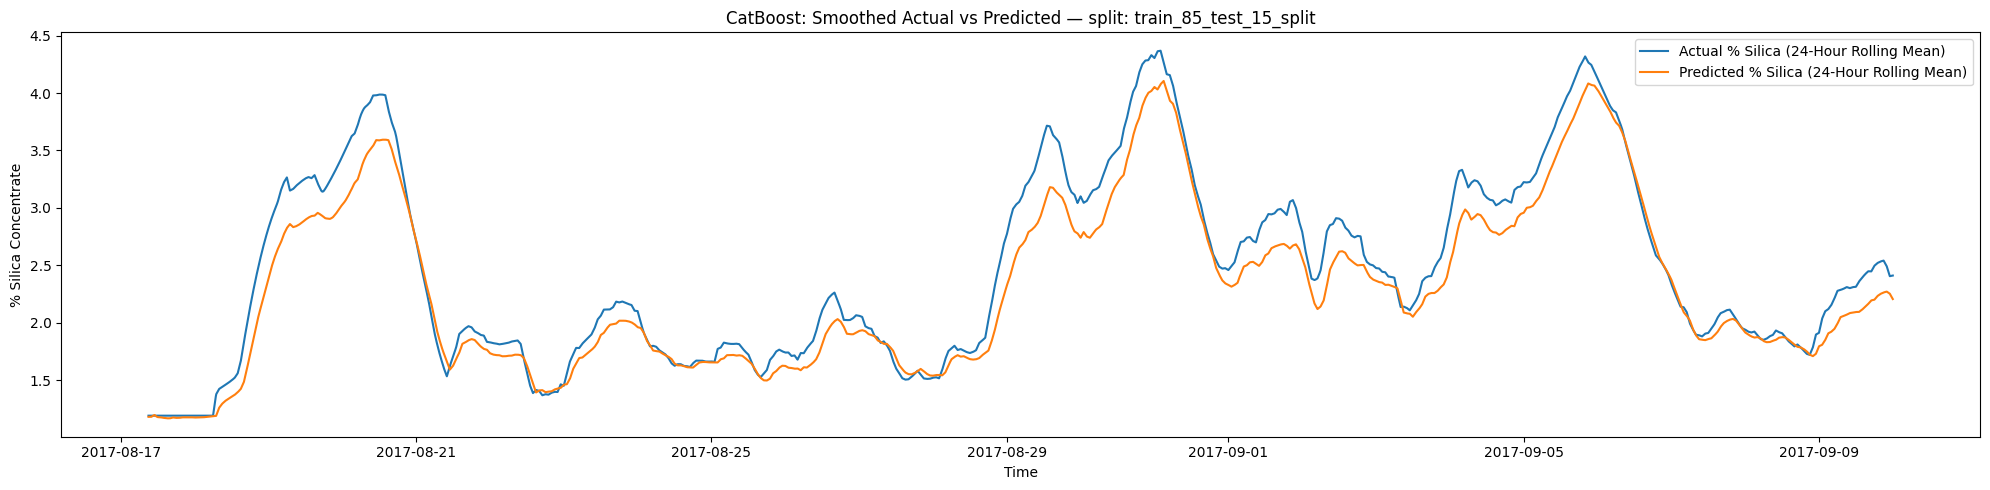

y_true_hourly_smooth shape: (567,)
y_pred_hourly_smooth shape: (567,)


date,2017-08-17 09:00:00,2017-08-17 10:00:00,2017-08-17 11:00:00,2017-08-17 12:00:00,2017-08-17 13:00:00,2017-08-17 14:00:00,2017-08-17 15:00:00,2017-08-17 16:00:00,2017-08-17 17:00:00,2017-08-17 18:00:00,...,2017-09-09 14:00:00,2017-09-09 15:00:00,2017-09-09 16:00:00,2017-09-09 17:00:00,2017-09-09 18:00:00,2017-09-09 19:00:00,2017-09-09 20:00:00,2017-09-09 21:00:00,2017-09-09 22:00:00,2017-09-09 23:00:00
0,1.19,1.19,1.19,1.19,1.19,1.19,1.19,1.19,1.19,1.19,...,2.391347,2.422097,2.447472,2.446653,2.495403,2.519389,2.532646,2.540458,2.492264,2.404681


date,2017-08-17 09:00:00,2017-08-17 10:00:00,2017-08-17 11:00:00,2017-08-17 12:00:00,2017-08-17 13:00:00,2017-08-17 14:00:00,2017-08-17 15:00:00,2017-08-17 16:00:00,2017-08-17 17:00:00,2017-08-17 18:00:00,...,2017-09-09 14:00:00,2017-09-09 15:00:00,2017-09-09 16:00:00,2017-09-09 17:00:00,2017-09-09 18:00:00,2017-09-09 19:00:00,2017-09-09 20:00:00,2017-09-09 21:00:00,2017-09-09 22:00:00,2017-09-09 23:00:00
0,1.179707,1.180503,1.195546,1.177306,1.175629,1.170778,1.166802,1.166892,1.17423,1.170775,...,2.112774,2.137899,2.163474,2.193821,2.199719,2.231891,2.250761,2.262914,2.270768,2.252737


In [44]:
plot_actual_vs_predicted_smoothed(df_all_features, train_85_test_15_split, results1)

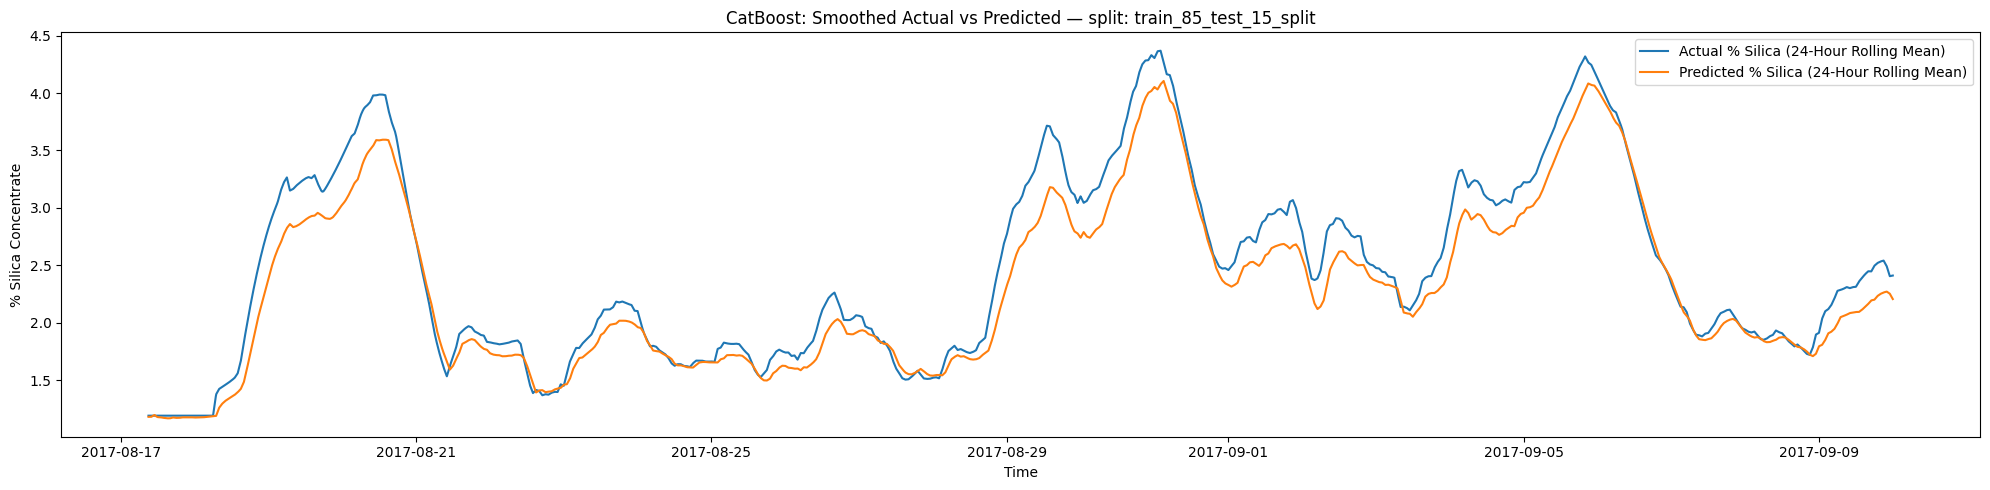

y_true_hourly_smooth shape: (567,)
y_pred_hourly_smooth shape: (567,)


date,2017-08-17 09:00:00,2017-08-17 10:00:00,2017-08-17 11:00:00,2017-08-17 12:00:00,2017-08-17 13:00:00,2017-08-17 14:00:00,2017-08-17 15:00:00,2017-08-17 16:00:00,2017-08-17 17:00:00,2017-08-17 18:00:00,...,2017-09-09 14:00:00,2017-09-09 15:00:00,2017-09-09 16:00:00,2017-09-09 17:00:00,2017-09-09 18:00:00,2017-09-09 19:00:00,2017-09-09 20:00:00,2017-09-09 21:00:00,2017-09-09 22:00:00,2017-09-09 23:00:00
0,1.19,1.19,1.19,1.19,1.19,1.19,1.19,1.19,1.19,1.19,...,2.391347,2.422097,2.447472,2.446653,2.495403,2.519389,2.532646,2.540458,2.492264,2.404681


date,2017-08-17 09:00:00,2017-08-17 10:00:00,2017-08-17 11:00:00,2017-08-17 12:00:00,2017-08-17 13:00:00,2017-08-17 14:00:00,2017-08-17 15:00:00,2017-08-17 16:00:00,2017-08-17 17:00:00,2017-08-17 18:00:00,...,2017-09-09 14:00:00,2017-09-09 15:00:00,2017-09-09 16:00:00,2017-09-09 17:00:00,2017-09-09 18:00:00,2017-09-09 19:00:00,2017-09-09 20:00:00,2017-09-09 21:00:00,2017-09-09 22:00:00,2017-09-09 23:00:00
0,1.179707,1.180503,1.195546,1.177306,1.175629,1.170778,1.166802,1.166892,1.17423,1.170775,...,2.112774,2.137899,2.163474,2.193821,2.199719,2.231891,2.250761,2.262914,2.270768,2.252737


In [43]:
###### resample('h').mean() ######
plot_actual_vs_predicted_smoothed(df_all_features, train_85_test_15_split, results1)

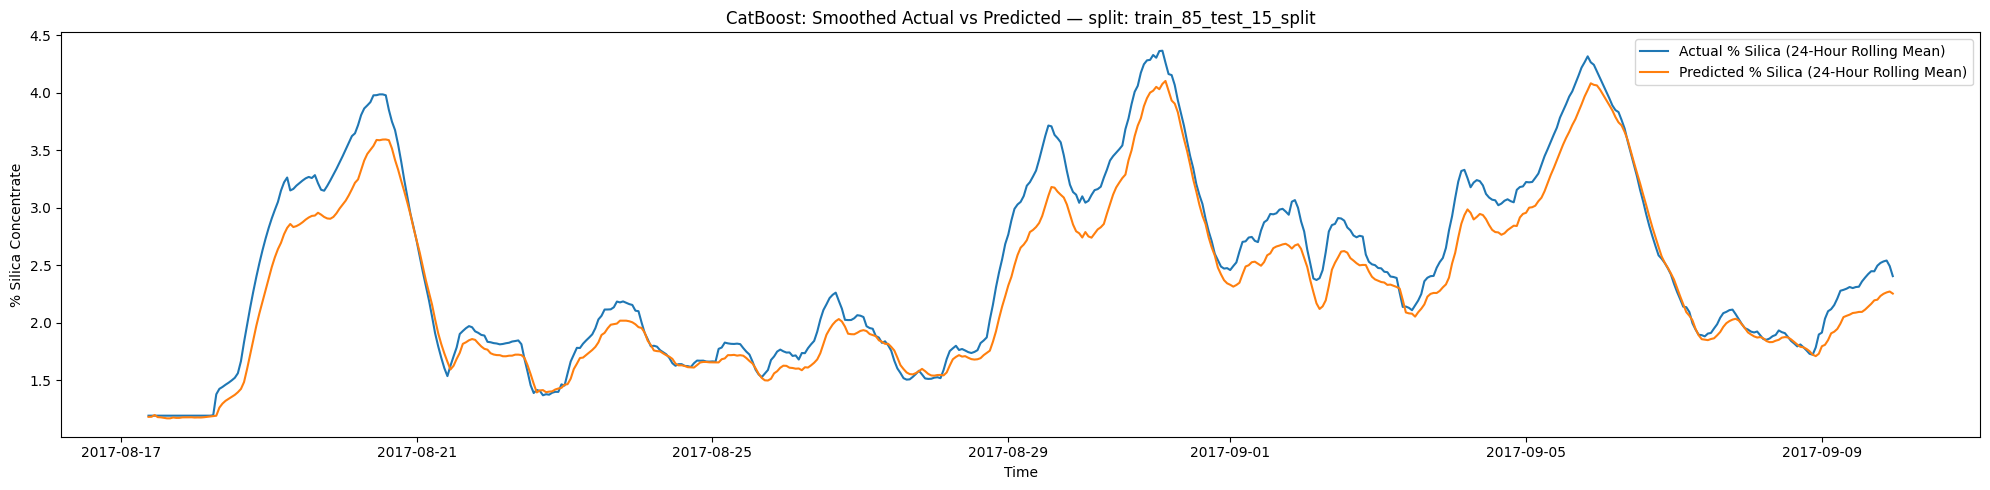

y_true_hourly_smooth shape: (567,)
y_pred_hourly_smooth shape: (567,)


In [37]:
###### iloc[::60] ######
plot_actual_vs_predicted_smoothed(df_all_features, train_85_test_15_split, results1)

**Can be seen from above plot that the best model from 85-15 split grid search (CatBoost) is generalizing well for a time range that it did not see during training.**

## 2. Visualize 1-59 Split Results

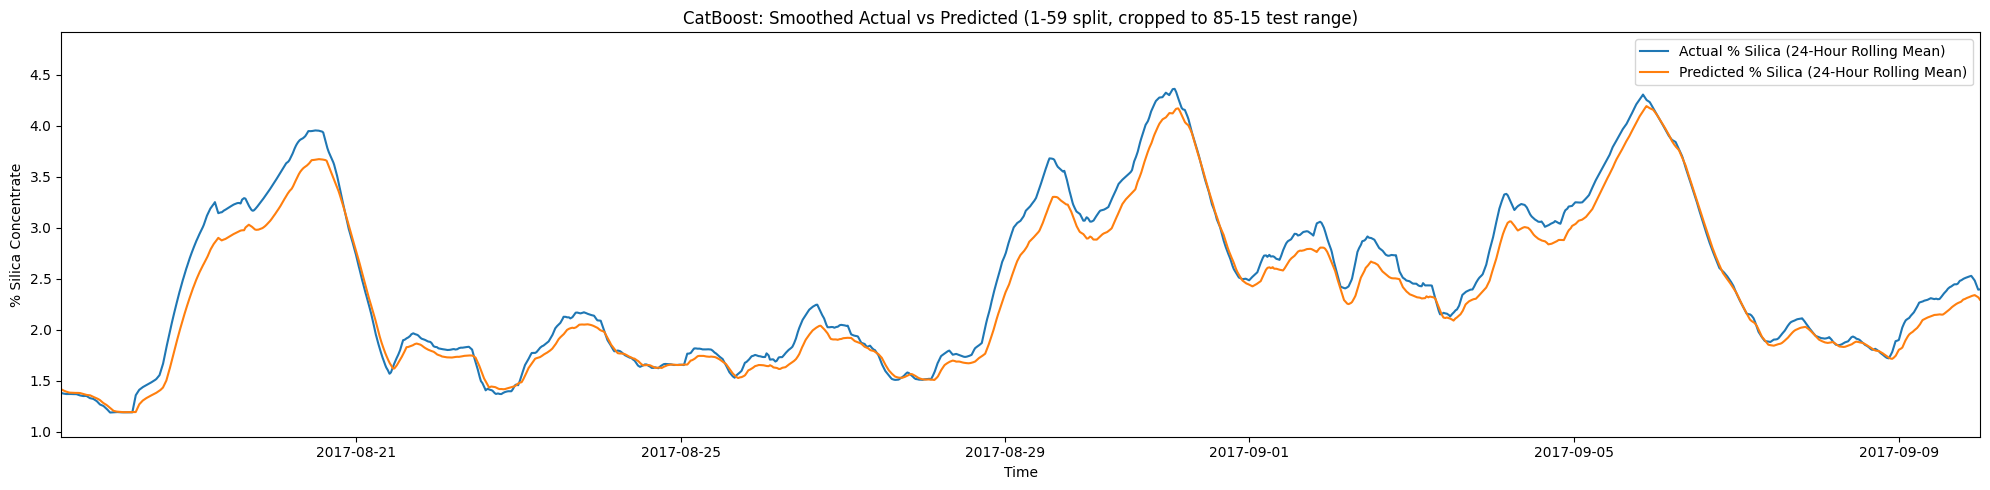

In [35]:
# plot_actual_vs_predicted_smoothed(df_all_features, train_1_test_59_split, results2)

# Get the test date range from the 85-15 split for cropping
_, _, X_test_85_15, _ = train_85_test_15_split(df_all_features)
start_date_85_15 = X_test_85_15.index.min()
end_date_85_15 = X_test_85_15.index.max()

# Replicate the logic of plot_actual_vs_predicted_smoothed from cell ca04b024-a5d6-4d22-9481-5cb693887717
# This is necessary because we need to set `xlim` for the plot, which is not a parameter of the original function.

# Parameters for the plot
current_df_features = df_all_features
current_split_func = train_1_test_59_split
current_results = results2
current_model_name = None # This means pick the best based on test_MAPE
current_rolling_window = 24*60

# 1. Recreate split for the 1-59 data (this is the data source for the current plot)
X_train_current, y_train_current, X_test_current, y_test_current = current_split_func(current_df_features)

# 2. Pick the best model from results2 (which corresponds to the 1-59 split)
if current_model_name is None:
    best_entry = min(current_results, key=lambda r: r["test_MAPE"])
else:
    best_entry = [r for r in current_results if r["model"] == current_model_name][0]

model = best_entry["best_estimator"]
name = best_entry["model"]

# 3. Predict using the best model on the 1-59 split test data
y_pred_current = model.predict(X_test_current)

# Convert to pandas Series with datetime index
y_true_current = pd.Series(y_test_current.values, index=X_test_current.index)
y_pred_current = pd.Series(y_pred_current, index=X_test_current.index)

# 4. Apply rolling average smoothing
y_true_smooth_current = y_true_current.rolling(current_rolling_window, min_periods=1).mean()
y_pred_smooth_current = y_pred_current.rolling(current_rolling_window, min_periods=1).mean()

# 5. Plot, applying the xlim derived from the 85-15 split
plt.figure(figsize=(20, 5))
plt.plot(y_true_smooth_current, label=f"Actual % Silica (24-Hour Rolling Mean)")
plt.plot(y_pred_smooth_current, label=f"Predicted % Silica (24-Hour Rolling Mean)")
plt.xlabel("Time")
plt.ylabel("% Silica Concentrate")
plt.title(f"{name}: Smoothed Actual vs Predicted (1-59 split, cropped to 85-15 test range)")
plt.legend()
plt.xlim(start_date_85_15, end_date_85_15) # Apply the cropping here
plt.tight_layout()
plt.show()

**Can be seen from above plot that the best model from 1-59 split grid search (LGBM) is excellent at filling gaps between hourly lab smaples that were seen during training.**

## 3. Final Conclusion

---

After assessing hyperparameter grid-search results for ElasticNet, CatBoost, and LightGBM on both the 85–15 and 1–59 train–test splits, we determined that the **85–15 split represents true forward-in-time generalization**. Under this setting, model performance lies in a realistic range (MAPE ~0.197–0.231, R² ~0.614–0.647), reflecting the genuine difficulty of predicting silica behavior in real-time across future months and operating regimes that were not observed during training.

In contrast, switching to the **1–59 split** yields much higher scores for all models—especially LightGBM (MAPE ~0.12, R² ~0.88). This is expected because the 1–59 split evaluates a fundamentally different task: **more so intra-hour interpolation**, not real-time predicting of % Silica Concentrate. Since % Silica Concentrate is constant within each hour, and the test rows belong to the exact same hour as the train row, the predictive problem becomes dramatically easier and the variance in the target collapses, naturally inflating R².

While the 1–59 split is appropriate for analyzing how well a soft sensor can fill the 59-minute gaps between hourly lab readings, these results **should not be interpreted as long-term real-time % Silica predictive accuracy**. The 85–15 split better captures the true predicting challenge, whereas the 1–59 split reflects more so interpolation capability. Based on this reasoning, we selected the **best-performing model under the 85–15 generalization split** as our final model for deployment: **CatBoost** with hyperparameters `{'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.03, 'n_estimators': 300}`, achieving a **MAPE of ~19.65%**.

---